# Лабораторна Робота №4
### **Тема:** Детекція об'єктів (YOLOv8/11 та SSD)

In [1]:
import os
import cv2
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ultralytics import YOLO
from scipy.spatial.distance import cdist

In [2]:
output_dir = 'output_lab4'
os.makedirs(output_dir, exist_ok=True)

In [3]:
# Завантажуємо базову Nano модель (yolo11n) та трохи більшу Small (yolo11s) для нашого бенчмарку
model_n = YOLO("yolo11n.pt") 
model_s = YOLO("yolo11s.pt") 
print("Моделі YOLO11n та YOLO11s успішно завантажені!")

Моделі YOLO11n та YOLO11s успішно завантажені!


### 1.1.1 Інференс на зображенні

In [4]:
test_images_dir = "test_images"
img_files = [f for f in os.listdir(test_images_dir) if f.endswith(('.jpg', '.png', '.jpeg'))]

if len(img_files) > 0:
    img_path = os.path.join(test_images_dir, img_files[0])
else:
    print(f"Помилка: Не знайдено зображень у папці {test_images_dir}")


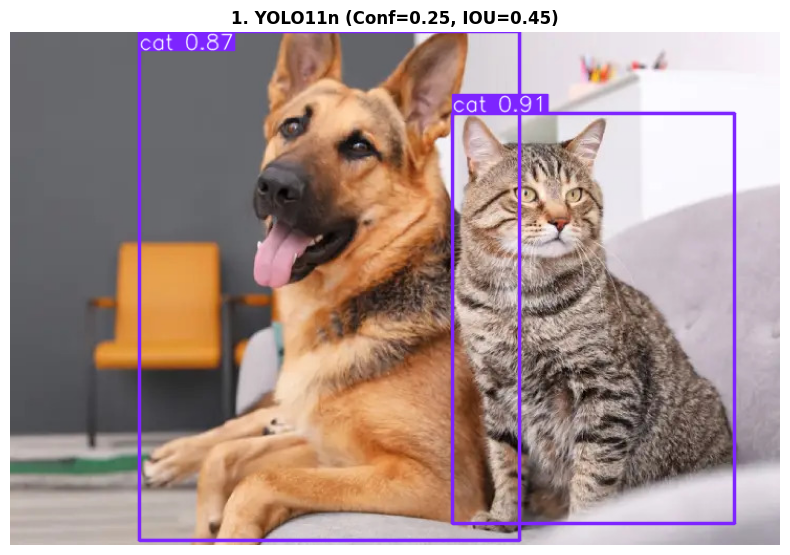

In [5]:
res_base = model_n(img_path, conf=0.25, iou=0.45, verbose=False)[0]

plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(res_base.plot(), cv2.COLOR_BGR2RGB))
plt.title("1. YOLO11n (Conf=0.25, IOU=0.45)", fontweight='bold', fontsize=12)
plt.axis('off')
plt.tight_layout()
plt.show()

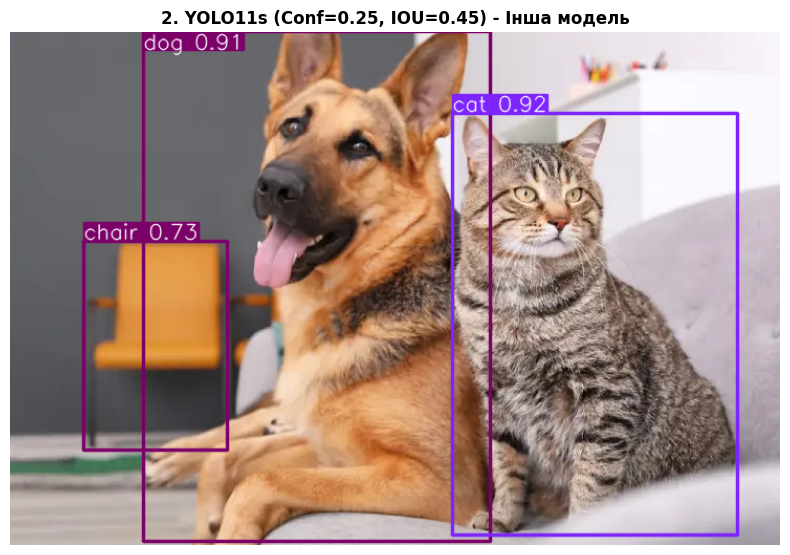

In [6]:
res_small = model_s(img_path, conf=0.25, iou=0.45, verbose=False)[0]

plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(res_small.plot(), cv2.COLOR_BGR2RGB))
plt.title("2. YOLO11s (Conf=0.25, IOU=0.45) - Інша модель", fontweight='bold', fontsize=12)
plt.axis('off')
plt.tight_layout()
plt.show()

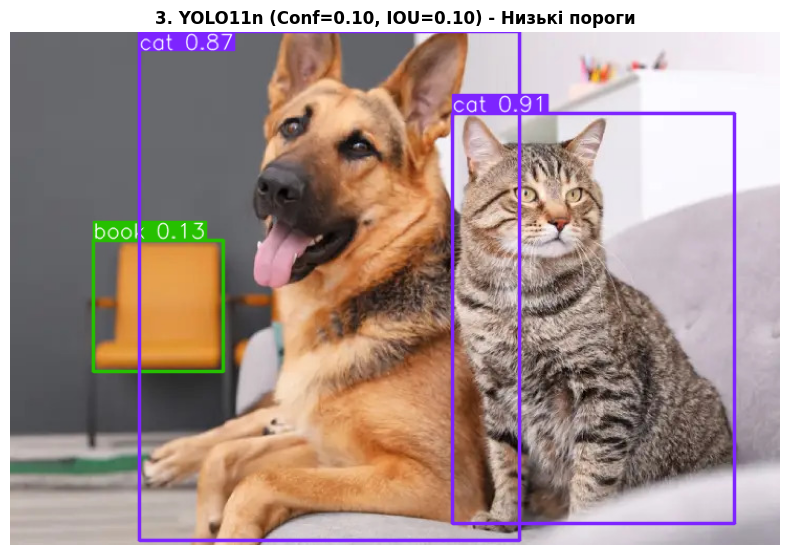

In [7]:
res_low = model_n(img_path, conf=0.10, iou=0.10, verbose=False)[0]

plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(res_low.plot(), cv2.COLOR_BGR2RGB))
plt.title("3. YOLO11n (Conf=0.10, IOU=0.10) - Низькі пороги", fontweight='bold', fontsize=12)
plt.axis('off')
plt.tight_layout()
plt.show()

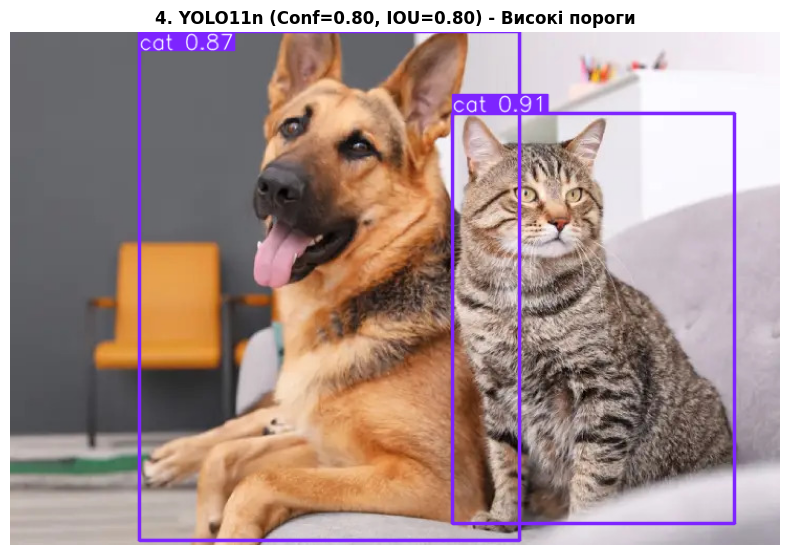

In [8]:
res_high = model_n(img_path, conf=0.80, iou=0.80, verbose=False)[0]

plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(res_high.plot(), cv2.COLOR_BGR2RGB))
plt.title("4. YOLO11n (Conf=0.80, IOU=0.80) - Високі пороги", fontweight='bold', fontsize=12)
plt.axis('off')
plt.tight_layout()
plt.show()

### 1.1.2 Відео інференс: Бенчмарк YOLO11n vs YOLO11s

In [9]:
video_path = "planes.mp4"

def process_video(model, model_name, video_path, max_frames=150):
    print(f"Обробка відео моделлю {model_name}")
    cap = cv2.VideoCapture(video_path)
    
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps_out = cap.get(cv2.CAP_PROP_FPS)
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out_video_path = os.path.join(output_dir, f"2_yolo_{model_name}_planes.mp4")
    out = cv2.VideoWriter(out_video_path, fourcc, fps_out, (width, height))
    
    fps_list = []
    conf_list = []
    frames_processed = 0
    snapshot_saved = False
    
    prev_time = time.time()
    
    while cap.isOpened() and frames_processed < max_frames:
        ret, frame = cap.read()
        if not ret:
            break
            
        # Інференс (conf=0.3, iou=0.5)
        results = model(frame, conf=0.3, iou=0.5, verbose=False)
        frame_out = results[0].plot()
        
        # Збираємо статистику впевненості
        boxes = results[0].boxes
        if len(boxes) > 0:
            avg_conf = np.mean(boxes.conf.cpu().numpy())
            conf_list.append(avg_conf)
            
            if not snapshot_saved and avg_conf > 0.5:
                cv2.imwrite(os.path.join(output_dir, f"3_snapshot_{model_name}.jpg"), frame_out)
                snapshot_saved = True
        
        # Розрахунок FPS
        curr_time = time.time()
        fps = 1.0 / (curr_time - prev_time)
        prev_time = curr_time
        fps_list.append(fps)
        
        # Візуалізація FPS
        cv2.putText(frame_out, f"FPS: {fps:.1f}", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
        out.write(frame_out)
        frames_processed += 1

    cap.release()
    out.release()
    
    avg_fps = np.mean(fps_list[1:]) if len(fps_list) > 1 else 0
    avg_confidence = np.mean(conf_list) if len(conf_list) > 0 else 0
    
    print(f"[{model_name}] Завершено. Середній FPS: {avg_fps:.1f}, Середня впевненість: {avg_confidence:.2f}")
    return avg_fps, avg_confidence

In [10]:
if os.path.exists(video_path):
    fps_n, conf_n = process_video(model_n, "YOLO11n", video_path)
    fps_s, conf_s = process_video(model_s, "YOLO11s", video_path)
else:
    print(f"Помилка: Файл {video_path} не знайдено")

Обробка відео моделлю YOLO11n
[YOLO11n] Завершено. Середній FPS: 12.7, Середня впевненість: 0.60
Обробка відео моделлю YOLO11s
[YOLO11s] Завершено. Середній FPS: 7.3, Середня впевненість: 0.66


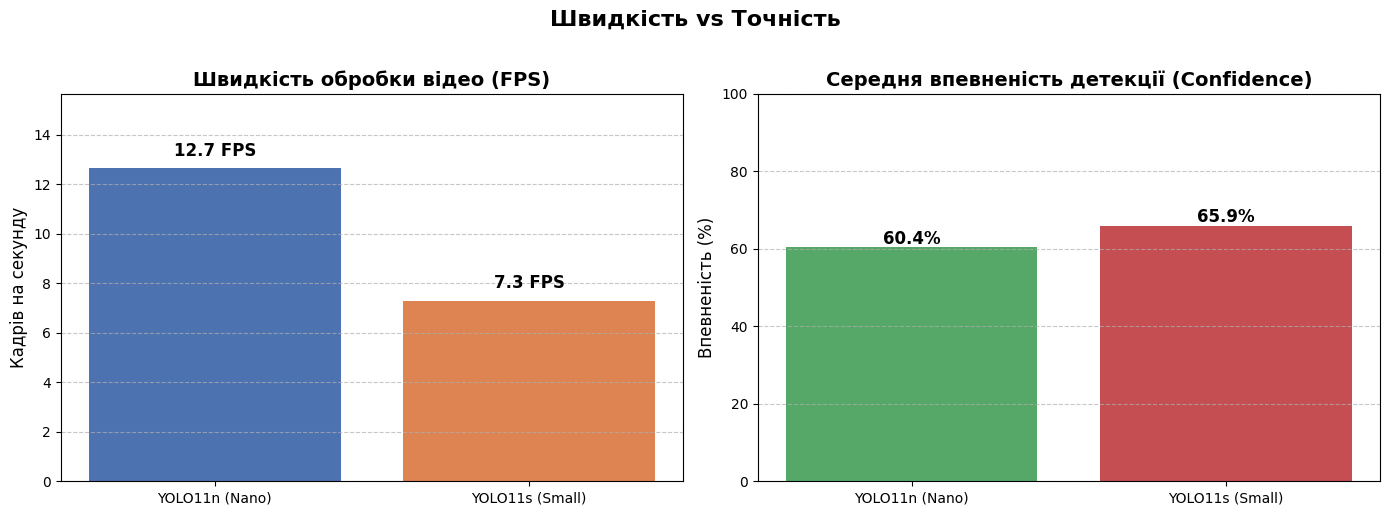

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), facecolor='white')

models = ['YOLO11n (Nano)', 'YOLO11s (Small)']
colors_fps = ['#4C72B0', '#DD8452']
colors_conf = ['#55A868', '#C44E52']

bars1 = ax1.bar(models, [fps_n, fps_s], color=colors_fps)
ax1.set_title('Швидкість обробки відео (FPS)', fontweight='bold', fontsize=14)
ax1.set_ylabel('Кадрів на секунду', fontsize=12)
ax1.set_ylim(0, max(fps_n, fps_s) + 3)
ax1.grid(axis='y', linestyle='--', alpha=0.7)
for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
            f"{bar.get_height():.1f} FPS", ha='center', fontweight='bold', fontsize=12)

bars2 = ax2.bar(models, [conf_n * 100, conf_s * 100], color=colors_conf)
ax2.set_title('Середня впевненість детекції (Confidence)', fontweight='bold', fontsize=14)
ax2.set_ylabel('Впевненість (%)', fontsize=12)
ax2.set_ylim(0, 100)
ax2.grid(axis='y', linestyle='--', alpha=0.7)
for bar in bars2:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
            f"{bar.get_height():.1f}%", ha='center', fontweight='bold', fontsize=12)

plt.suptitle("Швидкість vs Точність", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "4_yolo_benchmark.png"), dpi=150)
plt.show()

### 1.1.3 Тренування YOLO11 на власному датасеті

In [12]:
model = YOLO("yolo11n.pt")

# Запускаємо тренування. Використовуємо 20 епох для балансу між швидкістю і якістю.
# Зберігаємо результати прямо у нашу папку output_lab4
train_results = model.train(
    data="german_shepherd/data.yaml", 
    epochs=20, 
    imgsz=640, 
    batch=16, 
    project=output_dir, 
    name="train_gs"
)

New https://pypi.org/project/ultralytics/8.4.30 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.26  Python-3.11.5 torch-2.11.0+cpu CPU (Intel Core(TM) i5-10400F 2.90GHz)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=german_shepherd/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train_gs5, n

### Аналіз "Сайд-ефекту" на тестовому зображенні

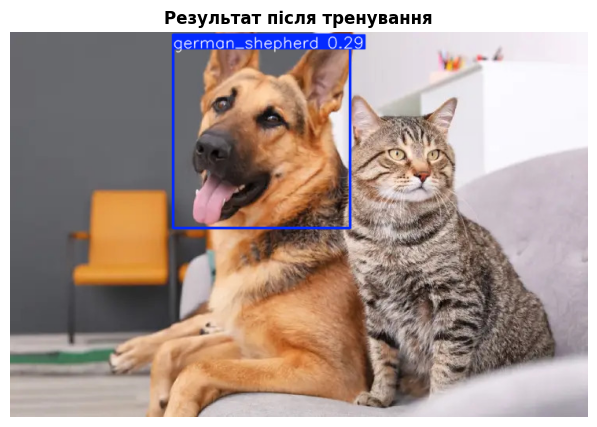

In [13]:
best_weights_path = os.path.join("runs", "detect", output_dir, "train_gs", "weights", "best.pt")
ft_model = YOLO(best_weights_path)

test_images_dir = "test_images"
img_files = [f for f in os.listdir(test_images_dir) if f.endswith(('.jpg', '.png', '.jpeg'))]
img_path = os.path.join(test_images_dir, img_files[0])

# Робимо інференс із низькими порогами
res_ft = ft_model(img_path, conf=0.1, iou=0.1, verbose=False)[0]

# Зберігаємо та виводимо результат
res_ft_plotted = res_ft.plot()
cv2.imwrite(os.path.join(output_dir, "5_yolo_finetuned_test.jpg"), res_ft_plotted)

plt.figure(figsize=(8, 5))
plt.imshow(cv2.cvtColor(res_ft_plotted, cv2.COLOR_BGR2RGB))
plt.title("Результат після тренування", fontweight='bold')
plt.axis('off')
plt.show()

### Графіки кривих навчання

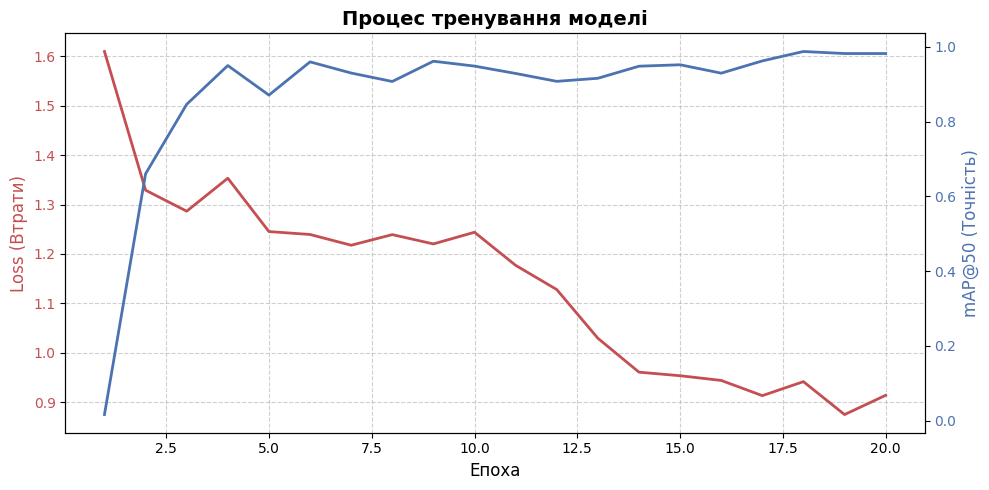

In [14]:
results_csv = os.path.join("runs", "detect", output_dir, "train_gs", "results.csv")

if os.path.exists(results_csv):
    df = pd.read_csv(results_csv)
    df.columns = df.columns.str.strip()
    
    fig, ax1 = plt.subplots(figsize=(10, 5), facecolor='white')
    
    # Графік Loss
    ax1.plot(df['epoch'], df['train/box_loss'], label='Train Box Loss', color='#C44E52', linewidth=2)
    ax1.set_xlabel('Епоха', fontsize=12)
    ax1.set_ylabel('Loss (Втрати)', color='#C44E52', fontsize=12)
    ax1.tick_params(axis='y', labelcolor='#C44E52')
    ax1.grid(True, linestyle='--', alpha=0.6)
    
    # Графік mAP50
    ax2 = ax1.twinx()
    ax2.plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP@50', color='#4C72B0', linewidth=2)
    ax2.set_ylabel('mAP@50 (Точність)', color='#4C72B0', fontsize=12)
    ax2.tick_params(axis='y', labelcolor='#4C72B0')
    
    plt.title('Процес тренування моделі', fontsize=14, fontweight='bold')
    fig.tight_layout()
    plt.savefig(os.path.join(output_dir, "6_training_curves.png"), dpi=150)
    plt.show()

### 1.1.4 Оцінка та помилки (FP та FN)

In [15]:
best_weights_path = os.path.join("runs", "detect", output_dir, "train_gs", "weights", "best.pt")
ft_model = YOLO(best_weights_path)

# Отримуємо метрики
metrics = ft_model.val(data="german_shepherd/data.yaml", verbose=False)
print(f"mAP@[.5:.95] = {metrics.box.map:.4f}")
print(f"mAP@0.50     = {metrics.box.map50:.4f}")
print(f"Precision    = {metrics.box.mp:.4f}")
print(f"Recall       = {metrics.box.mr:.4f}")

# Сортування помилок
val_images = os.path.join("german_shepherd", "valid", "images")
errors_fp_dir = os.path.join(output_dir, "errors", "FP")
errors_fn_dir = os.path.join(output_dir, "errors", "FN")
os.makedirs(errors_fp_dir, exist_ok=True)
os.makedirs(errors_fn_dir, exist_ok=True)

fp_count, fn_count = 0, 0

for img_name in os.listdir(val_images):
    val_img_path = os.path.join(val_images, img_name)
    res = ft_model(val_img_path, conf=0.25, iou=0.5, verbose=False)[0]
    
    for b in res.boxes:
        conf = b.conf.item() 
        
        if conf > 0.80:
            cv2.imwrite(os.path.join(errors_fp_dir, img_name), res.plot())
            fp_count += 1
        elif conf < 0.30:
            cv2.imwrite(os.path.join(errors_fn_dir, img_name), res.plot())
            fn_count += 1

print(f"Знайдено хибних спрацьовувань (FP, conf > 0.8): {fp_count}")
print(f"Знайдено пропусків/низької впевненості (FN, conf < 0.3): {fn_count}")

Ultralytics 8.4.26  Python-3.11.5 torch-2.11.0+cpu CPU (Intel Core(TM) i5-10400F 2.90GHz)
YOLO11n summary (fused): 101 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 2131.3746.6 MB/s, size: 269.7 KB)
val: Scanning D:\workspace\uni\Masters\CV\lab4\german_shepherd\valid\labels.cache... 19 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 19/19  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.3s/it 2.5s7.1s
                   all         19         19      0.949      0.842      0.988       0.66
Speed: 2.0ms preprocess, 104.2ms inference, 0.0ms loss, 4.6ms postprocess per image
Results saved to D:\workspace\uni\Masters\CV\lab4\runs\detect\val6
mAP@[.5:.95] = 0.6601
mAP@0.50     = 0.9875
Precision    = 0.9485
Recall       = 0.8421
Знайдено хибних спрацьовувань (FP, conf > 0.8): 0
Знайдено пропусків/низької впевненості (FN, conf < 0.3): 5


### 1.1.5 Експорт оновленої моделі (ONNX та NCNN)

In [16]:
export_times = {}

# 1. Експорт у ONNX
t0 = time.time()
onnx_path = ft_model.export(format="onnx", opset=12, dynamic=True)
export_times["ONNX"] = time.time() - t0
print("Експорт в ONNX завершено.")

Ultralytics 8.4.26  Python-3.11.5 torch-2.11.0+cpu CPU (Intel Core(TM) i5-10400F 2.90GHz)

PyTorch: starting from 'runs\detect\output_lab4\train_gs\weights\best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 5, 8400) (5.2 MB)

ONNX: starting export with onnx 1.20.1 opset 12...
ONNX: slimming with onnxslim 0.1.90...
ONNX: export success  3.7s, saved as 'runs\detect\output_lab4\train_gs\weights\best.onnx' (10.3 MB)

Export complete (3.9s)
Results saved to D:\workspace\uni\Masters\CV\lab4\runs\detect\output_lab4\train_gs\weights
Predict:         yolo predict task=detect model=runs\detect\output_lab4\train_gs\weights\best.onnx imgsz=640 
Validate:        yolo val task=detect model=runs\detect\output_lab4\train_gs\weights\best.onnx imgsz=640 data=german_shepherd/data.yaml  
Visualize:       https://netron.app
Експорт в ONNX завершено.


In [17]:
# 2. Експорт у NCNN
t0 = time.time()
ncnn_path = ft_model.export(format="ncnn")
export_times["NCNN"] = time.time() - t0
print("Експорт в NCNN завершено.")

Ultralytics 8.4.26  Python-3.11.5 torch-2.11.0+cpu CPU (Intel Core(TM) i5-10400F 2.90GHz)
WARNING NCNN export does not support end2end models, disabling end2end branch.

PyTorch: starting from 'runs\detect\output_lab4\train_gs\weights\best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 5, 8400) (5.2 MB)

NCNN: starting export with NCNN 1.0.20260114 and PNNX 20260112...
NCNN: export success  5.9s, saved as 'runs\detect\output_lab4\train_gs\weights\best_ncnn_model' (10.0 MB)

Export complete (6.1s)
Results saved to D:\workspace\uni\Masters\CV\lab4\runs\detect\output_lab4\train_gs\weights
Predict:         yolo predict task=detect model=runs\detect\output_lab4\train_gs\weights\best_ncnn_model imgsz=640 
Validate:        yolo val task=detect model=runs\detect\output_lab4\train_gs\weights\best_ncnn_model imgsz=640 data=german_shepherd/data.yaml  
Visualize:       https://netron.app
Експорт в NCNN завершено.


In [18]:
# Функція підрахунку розміру папки
def get_size_mb(path):
    if os.path.isfile(path):
        return os.path.getsize(path) / (1024 * 1024)
    elif os.path.isdir(path):
        total_size = 0
        for dirpath, _, filenames in os.walk(path):
            for f in filenames:
                fp = os.path.join(dirpath, f)
                total_size += os.path.getsize(fp)
        return total_size / (1024 * 1024)
    return 0

In [19]:
sizes = {
    "PyTorch (.pt)": get_size_mb(best_weights_path),
    "ONNX (.onnx)": get_size_mb(onnx_path),
    "NCNN (folder)": get_size_mb(ncnn_path)
}

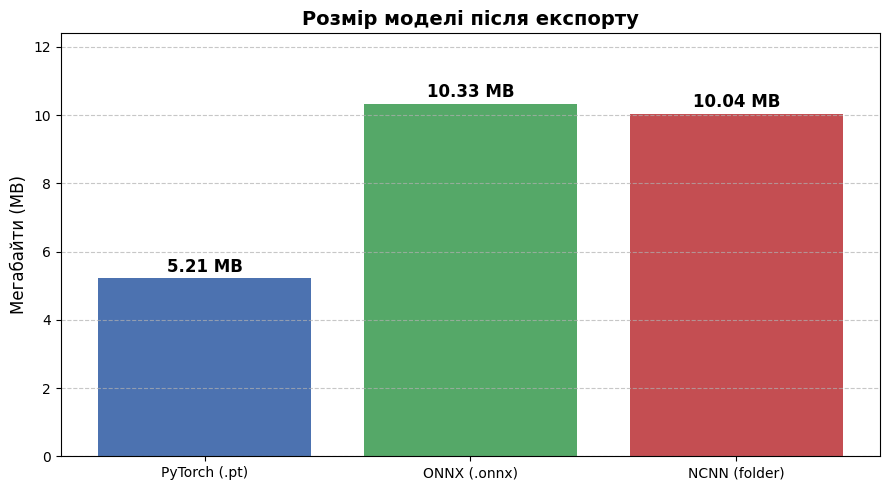

In [20]:
plt.figure(figsize=(9, 5), facecolor='white')
colors = ['#4C72B0', '#55A868', '#C44E52']
bars = plt.bar(list(sizes.keys()), list(sizes.values()), color=colors)

plt.title('Розмір моделі після експорту', fontsize=14, fontweight='bold')
plt.ylabel('Мегабайти (MB)', fontsize=12)
plt.ylim(0, max(sizes.values()) * 1.2)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for bar, size in zip(bars, sizes.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2, 
             f"{size:.2f} MB", ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "7_export_sizes.png"), dpi=150)
plt.show()

In [21]:
print("\nЧас витрачений на експорт:")
for name, t in export_times.items():
    print(f"- {name}: {t:.2f} секунд")


Час витрачений на експорт:
- ONNX: 3.88 секунд
- NCNN: 6.09 секунд


### 1.2 Класичний детектор SSD (Single Shot MultiBox Detector)

In [22]:
model_path = "ssd_mobilenet_v3.pb"
config_path = "ssd_mobilenet_v3.pbtxt"

# стандартні 80 класів COCO
classLabels = ["person", "bicycle", "car", "motorcycle", "airplane", "bus", "train", "truck", "boat",
               "traffic light", "fire hydrant", "street sign", "stop sign", "parking meter", "bench", 
               "bird", "cat", "dog", "horse", "sheep", "cow", "elephant", "bear", "zebra", "giraffe", 
               "hat", "backpack", "umbrella", "shoe", "eye glasses", "handbag", "tie", "suitcase", 
               "frisbee", "skis", "snowboard", "sports ball", "kite", "baseball bat", "baseball glove", 
               "skateboard", "surfboard", "tennis racket", "bottle", "plate", "wine glass", "cup", 
               "fork", "knife", "spoon", "bowl", "banana", "apple", "sandwich", "orange", "broccoli", 
               "carrot", "hot dog", "pizza", "donut", "cake", "chair", "couch", "potted plant", "bed", 
               "mirror", "dining table", "window", "desk", "toilet", "door", "tv", "laptop", "mouse", 
               "remote", "keyboard", "cell phone", "microwave", "oven", "toaster", "sink", "refrigerator", 
               "blender", "book", "clock", "vase", "scissors", "teddy bear", "hair drier", "toothbrush"]

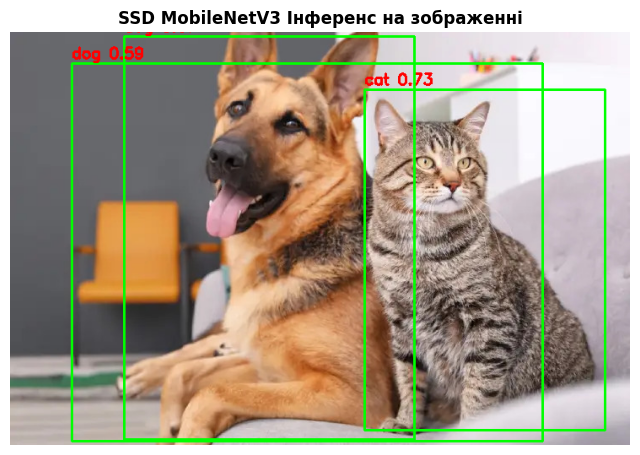

In [23]:
if os.path.exists(model_path) and os.path.exists(config_path):
    # Ініціалізація моделі SSD (OpenCV DNN)
    net = cv2.dnn_DetectionModel(model_path, config_path)
    net.setInputSize(320, 320)
    net.setInputScale(1.0/127.5)
    net.setInputMean((127.5, 127.5, 127.5))
    net.setInputSwapRB(True)
    
    # Використовуємо зображення з попередніх прикладів
    test_img_path = os.path.join("test_images", "test.jpg")
    if not os.path.exists(test_img_path):
        test_img_path = os.path.join("test_images", os.listdir("test_images")[0])
        
    img = cv2.imread(test_img_path)
    
    # Детекція
    classes, scores, boxes = net.detect(img, confThreshold=0.5, nmsThreshold=0.45)
    
    if len(classes) != 0:
        for cls, score, box in zip(classes.flatten(), scores.flatten(), boxes):
            # SSD повертає індекси класів з 1, а наш масив з 0 (тому cls-1)
            idx = cls - 1 if cls <= len(classLabels) else 0 
            label = f"{classLabels[idx]} {score:.2f}"
            
            x, y, w, h = box
            cv2.rectangle(img, (x, y), (x+w, y+h), (0, 255, 0), 2)
            cv2.putText(img, label, (x, y-6), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2)
    
    # Збереження та візуалізація
    ssd_img_out = os.path.join(output_dir, "8_ssd_img_out.jpg")
    cv2.imwrite(ssd_img_out, img)
    
    plt.figure(figsize=(8, 6))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("SSD MobileNetV3 Інференс на зображенні", fontweight='bold')
    plt.axis('off')
    plt.show()
else:
    print(f"Помилка: Модель SSD не знайдено")

### 1.2.2 Відео інференс SSD (football.mp4)

In [24]:
video_ssd_path = "football.mp4"

if os.path.exists(video_ssd_path) and 'net' in locals():
    cap = cv2.VideoCapture(video_ssd_path)
    
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps_out = cap.get(cv2.CAP_PROP_FPS)
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out_video_path = os.path.join(output_dir, "9_ssd_football.mp4")
    out = cv2.VideoWriter(out_video_path, fourcc, fps_out, (width, height))
    
    fps_list_ssd = []
    frames_processed = 0
    max_frames = 150
    
    prev_time = time.time()
    
    while cap.isOpened() and frames_processed < max_frames:
        ret, frame = cap.read()
        if not ret: break
        
        # Детекція SSD
        classes, scores, boxes = net.detect(frame, confThreshold=0.4, nmsThreshold=0.45)
        
        if len(classes) != 0:
            for cls, score, box in zip(classes.flatten(), scores.flatten(), boxes):
                idx = cls - 1 if cls <= len(classLabels) else 0 
                x, y, w, h = box
                cv2.rectangle(frame, (x, y), (x+w, y+h), (0, 255, 0), 2)
                cv2.putText(frame, f"{classLabels[idx]} {score:.2f}", (x, y-6), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2)
        
        curr_time = time.time()
        fps = 1.0 / (curr_time - prev_time)
        prev_time = curr_time
        fps_list_ssd.append(fps)
        
        cv2.putText(frame, f"FPS: {fps:.1f}", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 0), 2)
        out.write(frame)
        frames_processed += 1

    cap.release()
    out.release()
    avg_fps_ssd = np.mean(fps_list_ssd[1:]) if len(fps_list_ssd) > 1 else 0
    print(f"[SSD] Завершено. Середній FPS на відео football.mp4: {avg_fps_ssd:.1f}")
else:
    print(f"Помилка: Файл {video_ssd_path} не знайдено.")

[SSD] Завершено. Середній FPS на відео football.mp4: 10.8


### 2.1 Знаходження координат об'єкта (Адаптовано для Jupyter)

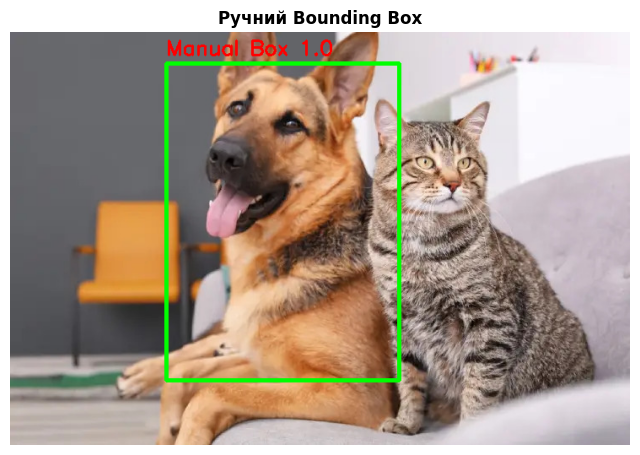

In [25]:
test_img_path = os.path.join("test_images", "test.jpg")
img = cv2.imread(test_img_path)

# Координати, які ми отримали за допомогою окремого скрипта manual_bbox.py
x, y, w, h = 185, 38, 276, 375

clone_img = img.copy()
cv2.rectangle(clone_img, (x, y), (x+w, y+h), (0, 255, 0), 3)
cv2.putText(clone_img, "Manual Box 1.0", (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 255), 2)

cv2.imwrite(os.path.join(output_dir, "10_manual_bbox.jpg"), clone_img)

plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(clone_img, cv2.COLOR_BGR2RGB))
plt.title("Ручний Bounding Box", fontweight='bold')
plt.axis('off')
plt.show()

### 2.2 Підрахунок на зображенні

Знайдено об'єктів: 2


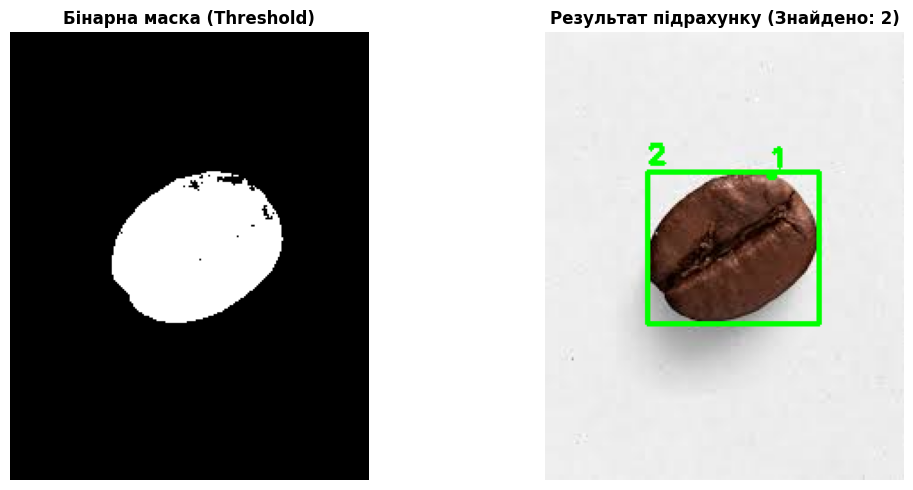

In [26]:
coffee_path = os.path.join("9_examples", "coffee.jpg")

if os.path.exists(coffee_path):
    img_coffee = cv2.imread(coffee_path)
    gray = cv2.cvtColor(img_coffee, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 130, 255, cv2.THRESH_BINARY_INV)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    count = len(contours)
    print(f"Знайдено об'єктів: {count}")
    
    img_coffee_res = img_coffee.copy()
    for i, cnt in enumerate(contours):
        x, y, w, h = cv2.boundingRect(cnt)
        cv2.rectangle(img_coffee_res, (x, y), (x+w, y+h), (0, 255, 0), 2)
        cv2.putText(img_coffee_res, str(i+1), (x, y-5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
    
    cv2.imwrite(os.path.join(output_dir, "11_coffee_counted.jpg"), img_coffee_res)
    
    # Виводимо порівняння (Маска vs Результат)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    ax1.imshow(thresh, cmap='gray')
    ax1.set_title("Бінарна маска (Threshold)", fontweight='bold')
    ax1.axis('off')
    ax2.imshow(cv2.cvtColor(img_coffee_res, cv2.COLOR_BGR2RGB))
    ax2.set_title(f"Результат підрахунку (Знайдено: {count})", fontweight='bold')
    ax2.axis('off')
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "11_coffee_plot.png"), dpi=100)
    plt.show()

### 2.3 MOG2 Підрахунок на відео (з очищенням шумів)

In [27]:
video_planes = "planes.mp4"
if os.path.exists(video_planes):
    cap = cv2.VideoCapture(video_planes)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    out = cv2.VideoWriter(os.path.join(output_dir, "12_mog2_planes.mp4"), 
                          cv2.VideoWriter_fourcc(*'mp4v'), 30, (width, height))
    
    fgbg = cv2.createBackgroundSubtractorMOG2(history=500, varThreshold=25, detectShadows=False)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    
    frames_processed = 0
    while cap.isOpened() and frames_processed < 200:
        ret, frame = cap.read()
        if not ret: break
        
        fg = cv2.medianBlur(frame, 5)
        fg_mask = fgbg.apply(fg)
        _, fg_mask = cv2.threshold(fg_mask, 200, 255, cv2.THRESH_BINARY)
        
        # Видаляємо шум
        fg_mask_clean = cv2.morphologyEx(fg_mask, cv2.MORPH_OPEN, kernel)
        
        contours, _ = cv2.findContours(fg_mask_clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        count = 0
        for c in contours:
            x, y, w, h = cv2.boundingRect(c)
            if w * h < 400: continue
            count += 1
            cv2.rectangle(frame, (x, y), (x+w, y+h), (0, 255, 0), 2)
            
        cv2.putText(frame, f"Active Objects: {count}", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 255), 2)
        cv2.putText(frame, "Noise Filter: ON", (10, 70), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 200, 0), 2)
        out.write(frame)
        frames_processed += 1
        
    cap.release()
    out.release()
    print("MOG2 обробка відео успішно завершена. Відео збережено.")

MOG2 обробка відео успішно завершена. Відео збережено.


### 2.4 Лінія перетину (Line-Crossing) з Траєкторіями

In [28]:
def assign_ids(prev_centroids, curr_centroids, prev_ids, max_dist=60):
    D = cdist(prev_centroids, curr_centroids) if len(prev_centroids) and len(curr_centroids) else np.empty((0,0))
    assigned = {}
    used_curr = set()
    new_ids = {}
    next_id = (max(prev_ids) + 1) if prev_ids else 0
    
    if D.size:
        for i in np.argsort(D, axis=None):
            r, c = divmod(i, D.shape[1])
            if D[r, c] > max_dist or r in assigned or c in used_curr: continue
            assigned[r] = c
            used_curr.add(c)
            
    for r, pid in enumerate(prev_ids):
        if r in assigned: new_ids[assigned[r]] = pid
    for c in range(len(curr_centroids)):
        if c not in new_ids.values() and c not in used_curr:
            new_ids[c] = next_id; next_id += 1
            
    return [new_ids.get(c, next_id+c) for c in range(len(curr_centroids))]

In [29]:
if os.path.exists(video_planes):
    cap = cv2.VideoCapture(video_planes)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    out = cv2.VideoWriter(os.path.join(output_dir, "13_line_crossing_planes.mp4"), 
                          cv2.VideoWriter_fourcc(*'mp4v'), 30, (width, height))
    
    fgbg = cv2.createBackgroundSubtractorMOG2(history=300, varThreshold=25, detectShadows=False)
    
    line_y = int(height * 0.4)
    prev_centroids, prev_ids = [], []
    seen = {}
    trajectories = {}
    count_up, count_down = 0, 0
    frames_processed = 0

    while cap.isOpened() and frames_processed < 250:
        ret, frame = cap.read()
        if not ret: break
        
        fg = cv2.medianBlur(frame, 5)
        fg_mask = fgbg.apply(fg)
        _, fg_mask = cv2.threshold(fg_mask, 200, 255, cv2.THRESH_BINARY)
        
        contours, _ = cv2.findContours(fg_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        curr_boxes, curr_centroids = [], []
        for c in contours:
            x, y, w, h = cv2.boundingRect(c)
            if w * h < 400: continue
            curr_boxes.append((x, y, w, h))
            curr_centroids.append((x + w/2, y + h/2))
            
        curr_ids = assign_ids(prev_centroids, curr_centroids, prev_ids, max_dist=60)
        
        for (x, y, w, h), (cx, cy), oid in zip(curr_boxes, curr_centroids, curr_ids):
            # Зберігаємо траєкторії
            if oid not in trajectories: trajectories[oid] = []
            trajectories[oid].append((int(cx), int(cy)))
            if len(trajectories[oid]) > 30: trajectories[oid].pop(0)
            
            # Малюємо траєкторію
            for i in range(1, len(trajectories[oid])):
                cv2.line(frame, trajectories[oid][i-1], trajectories[oid][i], (255, 0, 255), 2)
            
            prev_y = seen.get(oid, cy)
            if prev_y <= line_y < cy: count_down += 1
            elif prev_y >= line_y > cy: count_up += 1
            seen[oid] = cy
            
            cv2.rectangle(frame, (x, y), (x+w, y+h), (0, 255, 0), 2)
            cv2.putText(frame, f"ID {oid}", (x, y-6), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2)
            cv2.circle(frame, (int(cx), int(cy)), 4, (255, 0, 0), -1)
            
        cv2.line(frame, (0, line_y), (width, line_y), (0, 255, 255), 3)
        cv2.putText(frame, f"UP: {count_up} DOWN: {count_down}", (10, 40), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 0), 3)
        
        out.write(frame)
        prev_centroids, prev_ids = curr_centroids, curr_ids
        frames_processed += 1
        
    cap.release()
    out.release()
    print(f"Трекінг завершено. Підраховано: UP={count_up}, DOWN={count_down}. Відео збережено.")

Трекінг завершено. Підраховано: UP=3, DOWN=7. Відео збережено.
